In [19]:
import pandas as pd
import numpy as np

df = pd.read_csv("StudentsPerformance.csv")
df = df.select_dtypes(include=['number'])
df.head()



,math score,reading score,writing score
0,72,72,74
1,69,90,88
2,90,95,93
3,47,57,44
4,76,78,75


In [20]:
for col in df.columns:
    moyenne = df[col].mean()
    mediane = df[col].median()
    mode = df[col].mode()[0]
    print(f"Matière : {col}")
    print("Moyenne :", moyenne)
    print("Médiane :", mediane)
    if moyenne > mediane:
                print("Distribution asymétrique positive (queue à droite)")
    elif moyenne < mediane:
                print("Distribution asymétrique négative (queue à gauche)")
    else:
                print("Distribution symétrique")

Matière : math score
Moyenne : 66.089
Médiane : 66.0
Distribution asymétrique positive (queue à droite)
Matière : reading score
Moyenne : 69.169
Médiane : 70.0
Distribution asymétrique négative (queue à gauche)
Matière : writing score
Moyenne : 68.054
Médiane : 69.0
Distribution asymétrique négative (queue à gauche)


In [21]:
for col in df.select_dtypes(include=np.number).columns:
    etendue = df[col].max() - df[col].min()
    variance = df[col].var()
    ecart_type = df[col].std()

    print(f"Matière : {col}")
    print("Étendue :", etendue)
    print("Variance :", round(variance,2))
    print("Écart-type :", round(ecart_type,2))

    if ecart_type < 15:
        print("Faible variabilité (scores homogènes)")
    else:
        print("Forte variabilité (scores hétérogènes)")

Matière : math score
Étendue : 100
Variance : 229.92
Écart-type : 15.16
Forte variabilité (scores hétérogènes)
Matière : reading score
Étendue : 83
Variance : 213.17
Écart-type : 14.6
Faible variabilité (scores homogènes)
Matière : writing score
Étendue : 90
Variance : 230.91
Écart-type : 15.2
Forte variabilité (scores hétérogènes)


In [22]:
for col in df.select_dtypes(include=np.number).columns:
    Q1 = df[col].quantile(0.25)
    Q2 = df[col].quantile(0.5)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    limite_inf = Q1 - 1.5 * IQR
    limite_sup = Q3 + 1.5 * IQR

    valeurs_aberrantes = df[(df[col] < limite_inf) | (df[col] > limite_sup)][col]

    print(f"Matière : {col}")
    print("Q1 :", Q1)
    print("Q2 (Médiane) :", Q2)
    print("Q3 :", Q3)
    print("IQR :", IQR)
    print("Limite inférieure :", round(limite_inf,2))
    print("Limite supérieure :", round(limite_sup,2))

    if valeurs_aberrantes.empty:
        print("Pas de valeurs aberrantes")
    else:
        print("Valeurs aberrantes :", valeurs_aberrantes.values)
    print("\n")

Matière : math score
Q1 : 57.0
Q2 (Médiane) : 66.0
Q3 : 77.0
IQR : 20.0
Limite inférieure : 27.0
Limite supérieure : 107.0
Valeurs aberrantes : [18  0 22 24 26 19 23  8]


Matière : reading score
Q1 : 59.0
Q2 (Médiane) : 70.0
Q3 : 79.0
IQR : 20.0
Limite inférieure : 29.0
Limite supérieure : 109.0
Valeurs aberrantes : [17 26 28 23 24 24]


Matière : writing score
Q1 : 57.75
Q2 (Médiane) : 69.0
Q3 : 79.0
IQR : 21.25
Limite inférieure : 25.88
Limite supérieure : 110.88
Valeurs aberrantes : [10 22 19 15 23]




HISTOGRAMMES


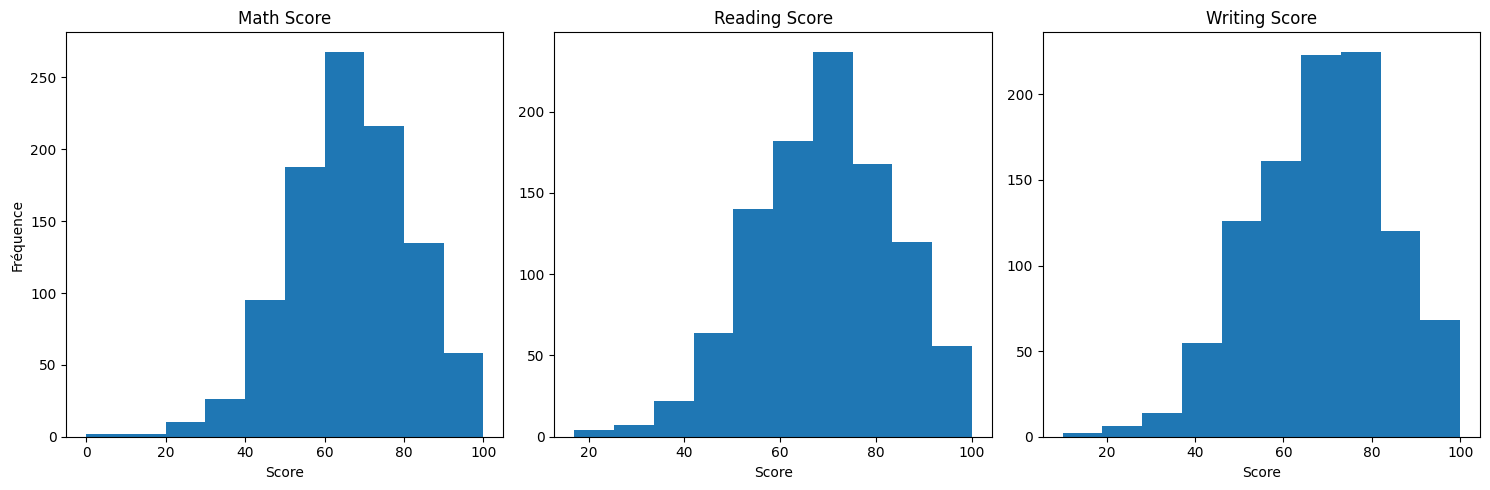

In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("StudentsPerformance.csv")
df = df.select_dtypes(include=['number'])

print("HISTOGRAMMES")

plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
plt.hist(df["math score"])
plt.title("Math Score")
plt.xlabel("Score")
plt.ylabel("Fréquence")

plt.subplot(1,3,2)
plt.hist(df["reading score"])
plt.title("Reading Score")
plt.xlabel("Score")


plt.subplot(1,3,3)
plt.hist(df["writing score"])
plt.title("Writing Score")
plt.xlabel("Score")

plt.tight_layout()
plt.show()


BOXPLOTS


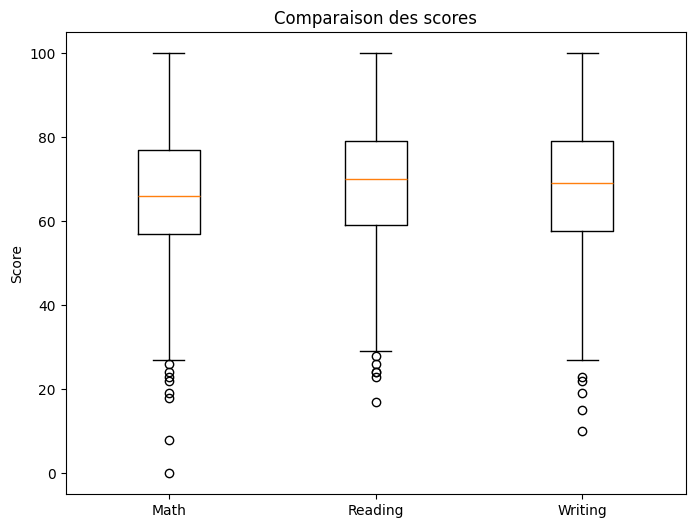

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("StudentsPerformance.csv")
df = df.select_dtypes(include=['number'])

print("BOXPLOTS")

plt.figure(figsize=(8,6))

plt.boxplot([df["math score"],
             df["reading score"],
             df["writing score"]])

plt.xticks([1,2,3], ["Math", "Reading", "Writing"])
plt.title("Comparaison des scores")
plt.ylabel("Score")

plt.show()
